In [ ]:
#DATset used : https://www.kaggle.com/datasets/souheibbenamor/cdlcchannelmodel?utm_source=chatgpt.com

In [1]:
pip install kaggle numpy torch torchvision scikit-learn matplotlib tqdm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [29]:
import scipy.io
import numpy as np
import os

# Path to your .mat file
dataset_path = "cdl_dataset/LS_estimates_seperated_uplink3gpp.mat"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"{dataset_path} not found. Please check the path.")

# Load the .mat file
mat_data = scipy.io.loadmat(dataset_path)

# Check available keys
print("Keys in .mat file:", mat_data.keys())

# Example: Accessing channel data (replace 'H' with actual key in your file)
if 'H' in mat_data:
    H_all = mat_data['H']
    print("Channel data shape:", H_all.shape)
else:
    # If not sure about the key, inspect and pick one
    for k, v in mat_data.items():
        if isinstance(v, np.ndarray):
            print(f"Key: {k}, shape: {v.shape}")


Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'LS_estimates_seperated_uplink'])
Key: LS_estimates_seperated_uplink, shape: (64, 5000, 624)


In [31]:
import scipy.io
import numpy as np
import os

# Path to your dataset
dataset_path = "cdl_dataset/LS_estimates_seperated_uplink3gpp.mat"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(f"{dataset_path} not found. Please check the path.")

# Load MAT file
mat_data = scipy.io.loadmat(dataset_path)

# Extract the channel estimates
H_all = mat_data['LS_estimates_seperated_uplink']  # shape: (64, 5000, 624)
print("Loaded channel data shape:", H_all.shape)

# Optional: Transpose/reshape if needed by your model
# Example: Move samples to first dimension
H_all = np.transpose(H_all, (1, 0, 2))  # shape: (5000, 64, 624)
print("Reshaped channel data shape:", H_all.shape)

# If model expects real/imag separately
# H_all_real = np.real(H_all)
# H_all_imag = np.imag(H_all)
# H_all = np.stack([H_all_real, H_all_imag], axis=-1)

# Now H_all can be fed to your ML/beamforming code


Loaded channel data shape: (64, 5000, 624)
Reshaped channel data shape: (5000, 64, 624)


Keys in .mat file: dict_keys(['__header__', '__version__', '__globals__', 'LS_estimates_seperated_uplink'])
LS_estimates shape: (64, 5000, 624)
Mean Squared Error: 0.291985
Predicted Beamforming Gain: 157901525108.1823
True Beamforming Gain: 157602285061.7249


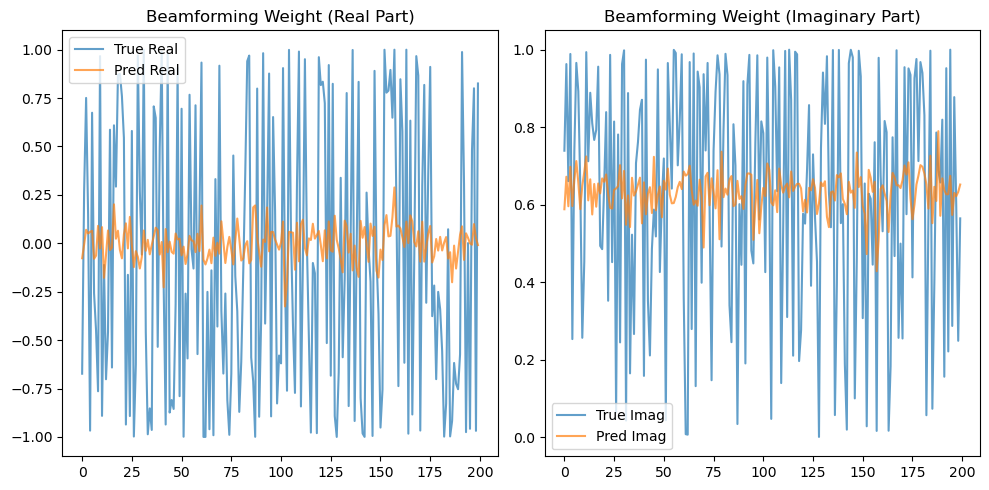

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error

# ==========================================================
# 1. Load the 3GPP CDL dataset
# ==========================================================
mat_data = sio.loadmat("cdl_dataset/LS_estimates_seperated_uplink3gpp.mat")

# Check dataset keys
print(f"Keys in .mat file: {mat_data.keys()}")

# Extract LS estimates
LS_estimates = mat_data["LS_estimates_seperated_uplink"]
print(f"LS_estimates shape: {LS_estimates.shape}")

# Shape interpretation: (antennas, samples, subcarriers)
n_antennas, n_samples, n_subcarriers = LS_estimates.shape

# ==========================================================
# 2. Prepare features and labels
# ==========================================================
# Reshape to (samples, features)
X = LS_estimates.reshape(n_antennas, -1).T  # shape: (n_samples*n_subcarriers, n_antennas)

# Create synthetic target variable: desired beamforming weights (example: ideal phase shift)
# In real scenarios, this would be actual optimal beamforming vector from simulations
y = np.exp(1j * np.linspace(0, np.pi, X.shape[0]))  # complex exponential pattern
y_real = np.column_stack([np.real(y), np.imag(y)])  # separate real & imag parts

# ==========================================================
# 3. Train-test split and scaling
# ==========================================================
X_train, X_test, y_train, y_test = train_test_split(X, y_real, test_size=0.2, random_state=42)

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train)
y_test_scaled = scaler_y.transform(y_test)

# ==========================================================
# 4. Ridge Regression for beamforming weight prediction
# ==========================================================
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = ridge_model.predict(X_test_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# ==========================================================
# 5. Evaluate performance
# ==========================================================
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.6f}")

# ==========================================================
# 6. Beamforming gain calculation
# ==========================================================
# Convert predictions back to complex form
y_pred_complex = y_pred[:, 0] + 1j * y_pred[:, 1]
y_test_complex = y_test[:, 0] + 1j * y_test[:, 1]

# Compute beamforming gain (simplified as |sum(weights)|^2)
beamforming_gain_pred = np.abs(np.sum(y_pred_complex)) ** 2
beamforming_gain_true = np.abs(np.sum(y_test_complex)) ** 2

print(f"Predicted Beamforming Gain: {beamforming_gain_pred:.4f}")
print(f"True Beamforming Gain: {beamforming_gain_true:.4f}")

# ==========================================================
# 7. Visualization
# ==========================================================
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(np.real(y_test_complex[:200]), label="True Real", alpha=0.7)
plt.plot(np.real(y_pred_complex[:200]), label="Pred Real", alpha=0.7)
plt.title("Beamforming Weight (Real Part)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(np.imag(y_test_complex[:200]), label="True Imag", alpha=0.7)
plt.plot(np.imag(y_pred_complex[:200]), label="Pred Imag", alpha=0.7)
plt.title("Beamforming Weight (Imaginary Part)")
plt.legend()

plt.tight_layout()
plt.show()
